<a href="https://colab.research.google.com/github/cncPomper/MMC/blob/master/MMC_lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

import os

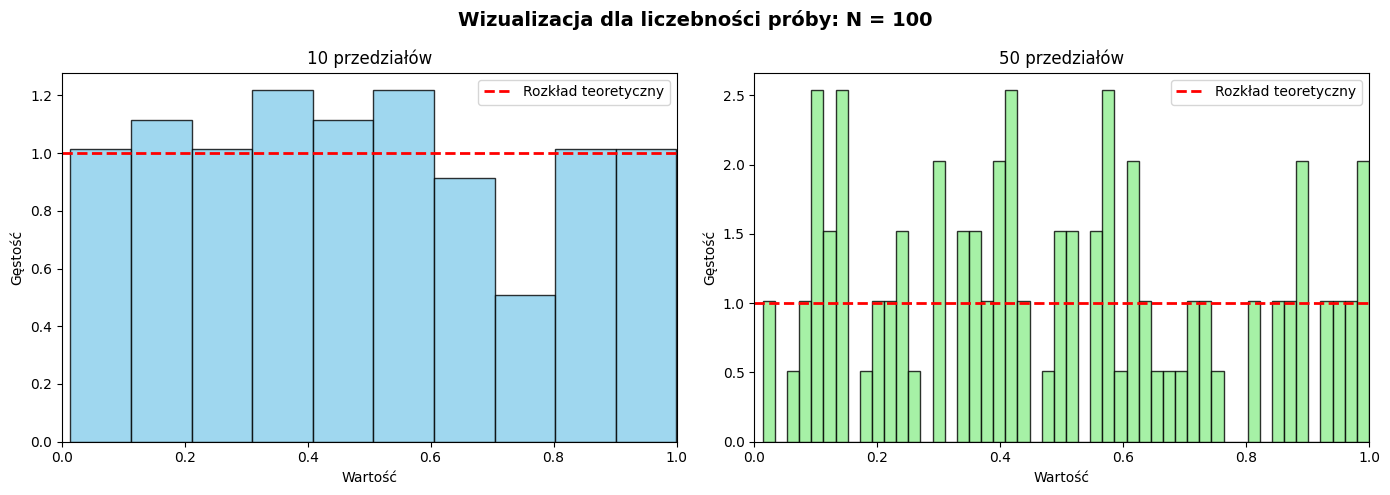

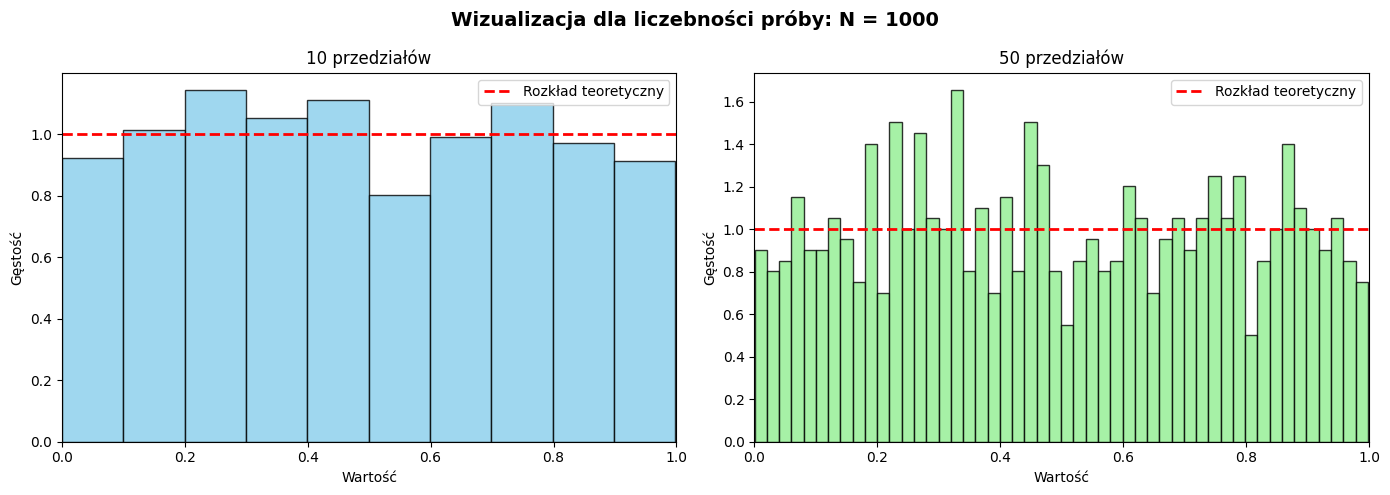

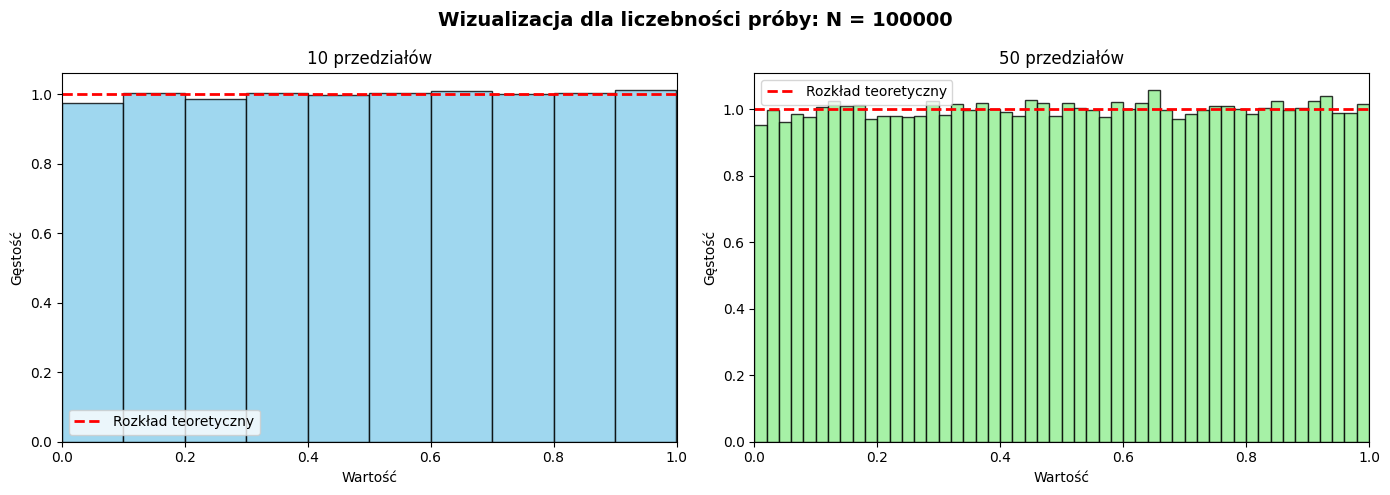

In [4]:
# Konfiguracja: różne wielkości prób, aby zaobserwować wpływ liczebności
wielkosci_prob = [100, 1000, 100000]
nazwa_pliku_prefix = "liczby_losowe_"

for N in wielkosci_prob:
    nazwa_pliku = nazwa_pliku_prefix + str(N) + ".txt"
    # 1. Generacja liczb z rozkładu równomiernego (od 0 do 1)
    # Odpowiednik generatora z GSL / std::random w C++
    liczby = np.random.uniform(0, 1, N)

    # 2. Zapis wygenerowanych liczb do pliku tekstowego
    np.savetxt(nazwa_pliku, liczby)

    # 3. Odczyt wygenerowanych liczb z pliku tekstowego
    liczby_z_pliku = np.loadtxt(nazwa_pliku)

    # 4. Wykreślenie histogramów
    # Używamy density=True, aby znormalizować pole pod histogramem do 1,
    # co pozwala łatwo nanieść rozkład teoretyczny (dla U(0,1) y=1)
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Wizualizacja dla liczebności próby: N = {N}", fontsize=14, fontweight='bold')

    # Rozkład teoretyczny (linia pozioma na wysokości 1)
    teoretyczny_x = [0, 1]
    teoretyczny_y = [1, 1]

    # Histogram 1 - 10 przedziałów (bins=10)
    axs[0].hist(liczby_z_pliku, bins=10, density=True, color='skyblue', edgecolor='black', alpha=0.8)
    axs[0].plot(teoretyczny_x, teoretyczny_y, 'r--', linewidth=2, label='Rozkład teoretyczny')
    axs[0].set_title('10 przedziałów')
    axs[0].set_xlabel('Wartość')
    axs[0].set_ylabel('Gęstość')
    axs[0].set_xlim(0, 1)
    axs[0].legend()

    # Histogram 2 - 50 przedziałów (bins=50)
    axs[1].hist(liczby_z_pliku, bins=50, density=True, color='lightgreen', edgecolor='black', alpha=0.8)
    axs[1].plot(teoretyczny_x, teoretyczny_y, 'r--', linewidth=2, label='Rozkład teoretyczny')
    axs[1].set_title('50 przedziałów')
    axs[1].set_xlabel('Wartość')
    axs[1].set_ylabel('Gęstość')
    axs[1].set_xlim(0, 1)
    axs[1].legend()

    plt.tight_layout()
    plt.show()

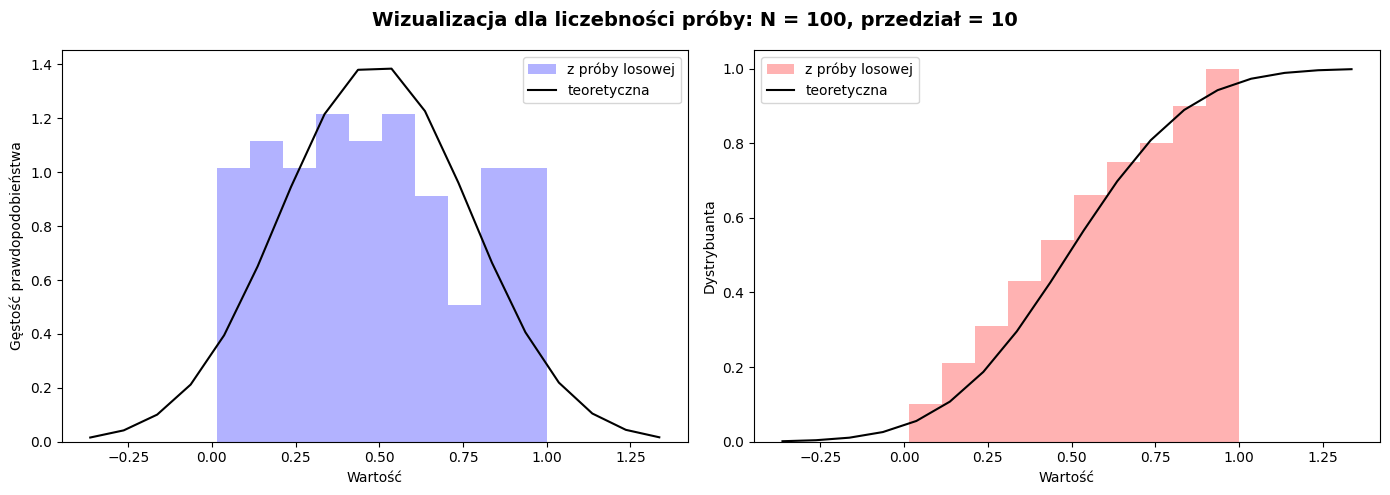

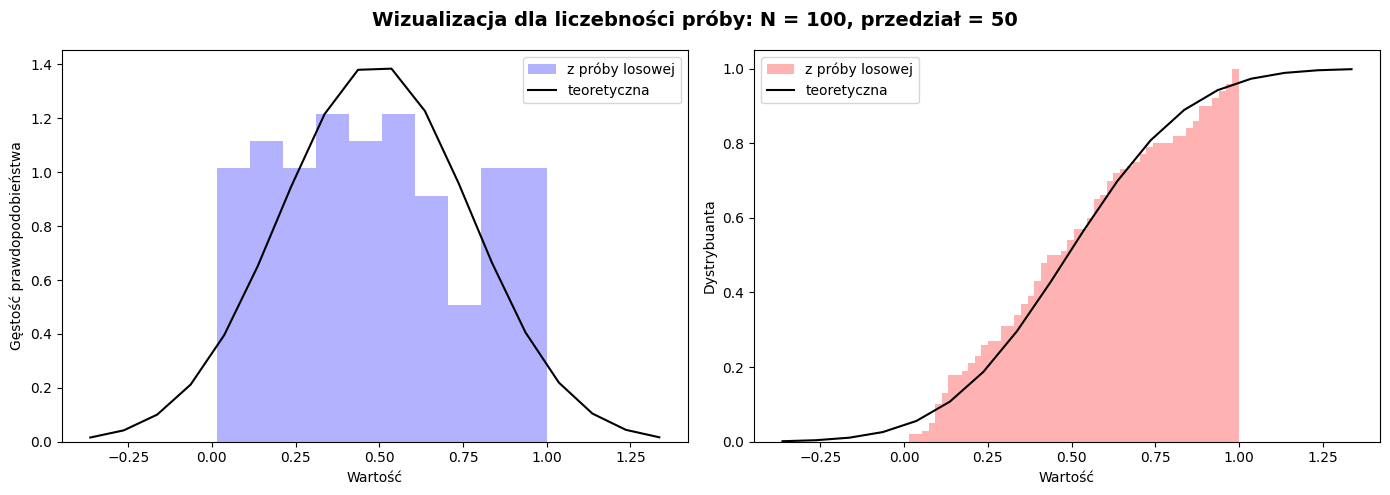

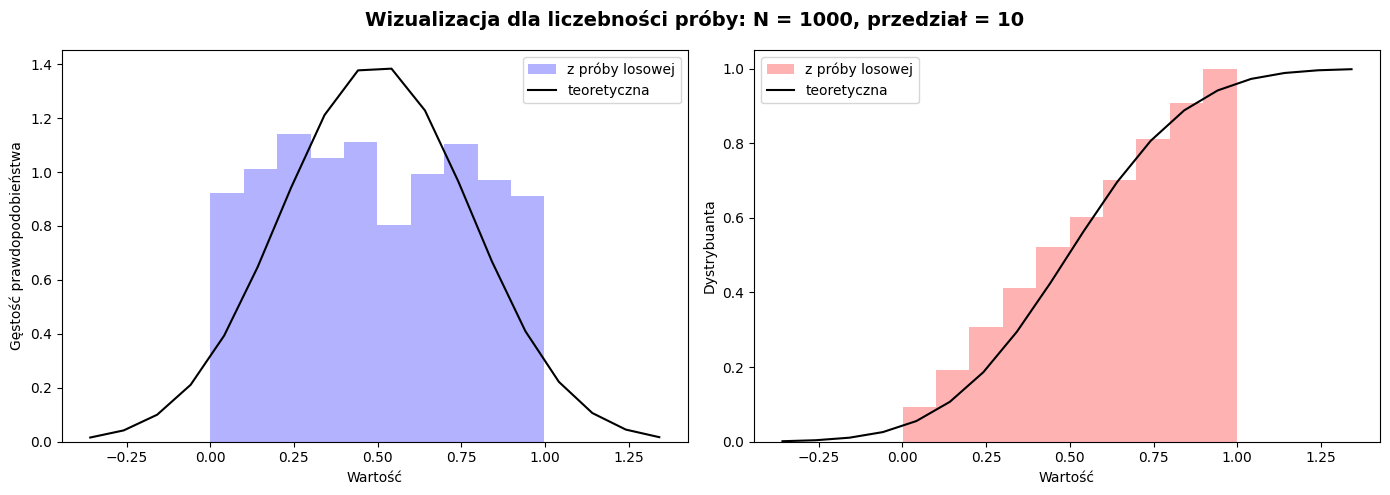

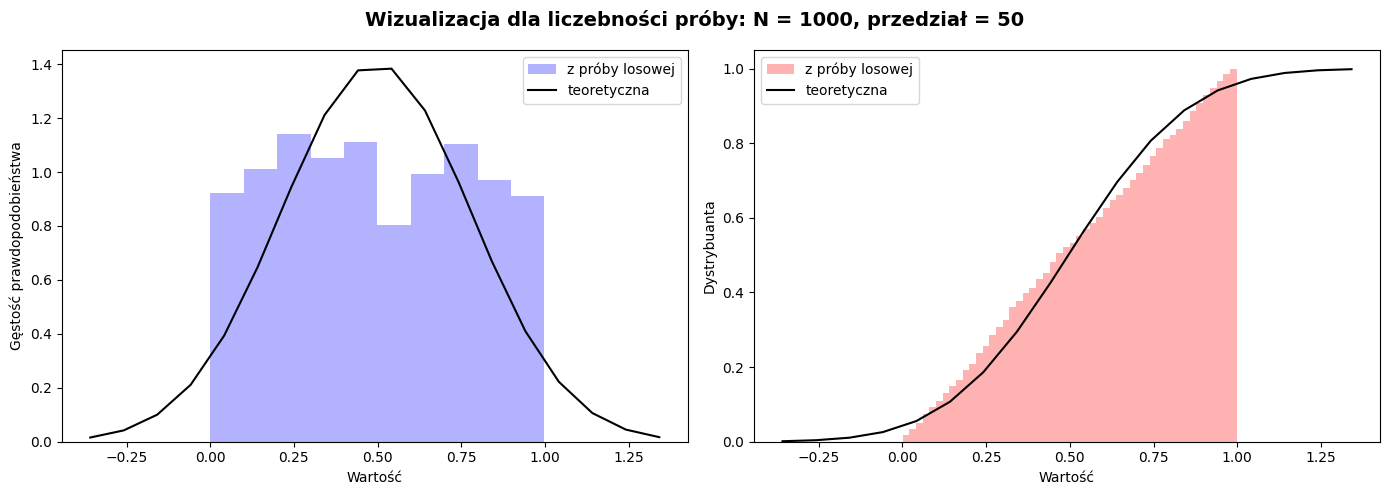

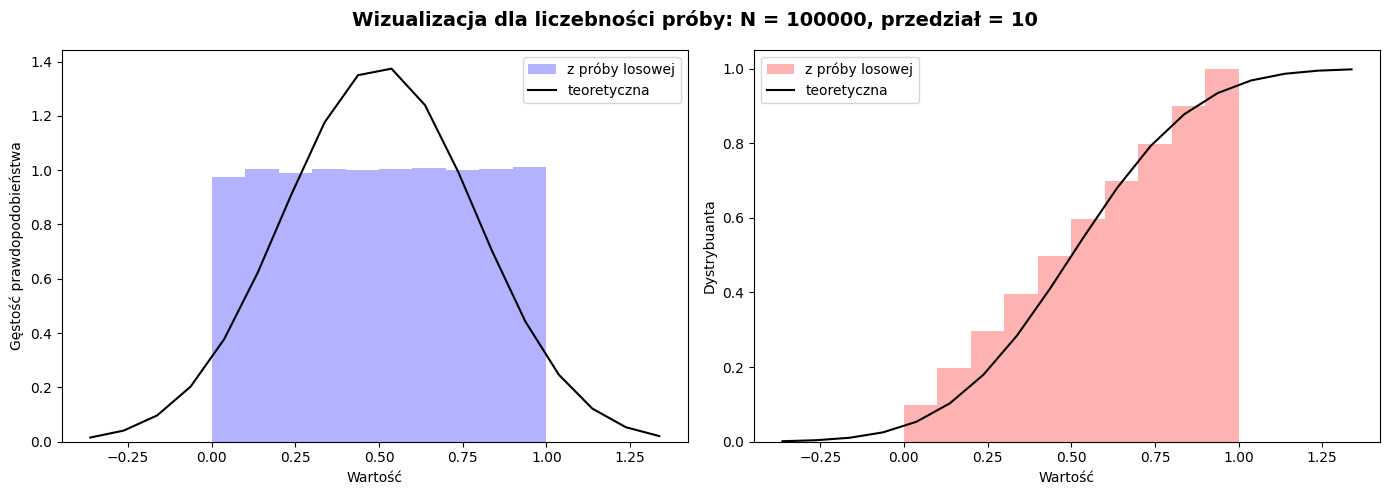

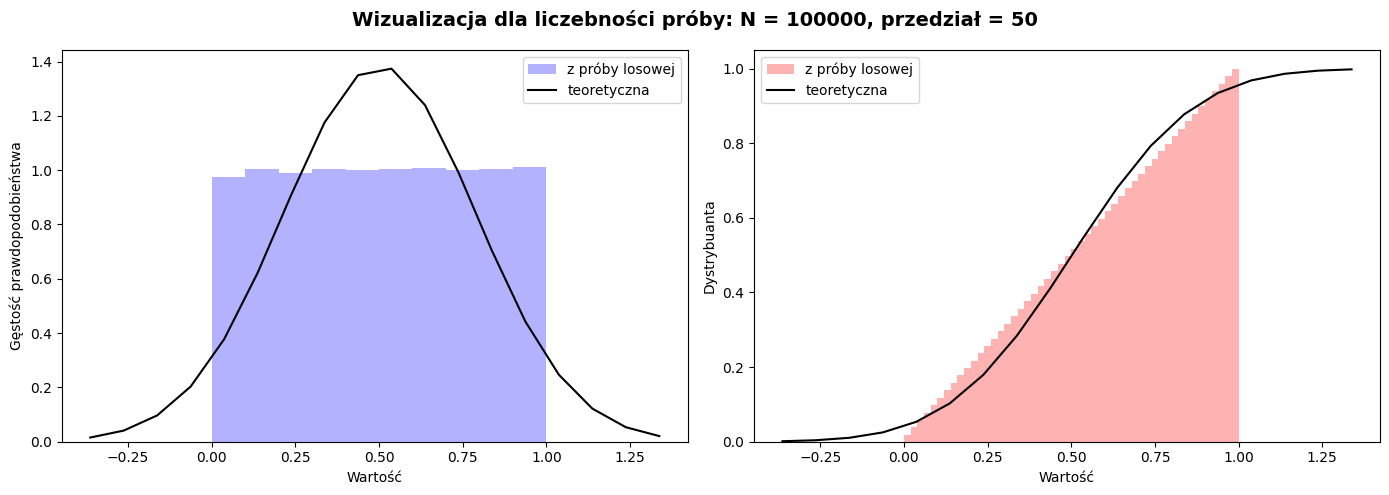

In [20]:
for N in wielkosci_prob:
  nazwa_pliku = nazwa_pliku_prefix + str(N) + ".txt"

  dane = np.loadtxt(nazwa_pliku, unpack=True)

  # Wartości teoretyczne wartości oczekiwanej i odchylenia standardowego.
  wart_oczek = np.mean(dane)
  odch_std   = np.std(dane, ddof=1)

  # Wartości na osi X histogramu.
  dziedzina = np.arange(wart_oczek-3*odch_std, wart_oczek+3*odch_std, 0.1)
  # Teoretyczna funkcja gęstości prawdopodobieństwa rozkładu normalnego o zadanych parametrach.
  fgp = norm.pdf(dziedzina, wart_oczek, odch_std)
  # Rysujemy histogram częstości. Histogram liczebności uzyskalibyśmy przy 'normed=False'.
  # W nowszej wersji NumPy zamiast 'normed' używamy parametru 'density'.
  for bin in [10, 50]:
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Wizualizacja dla liczebności próby: N = {N}, przedział = {bin}", fontsize=14, fontweight='bold')

    axs[0].hist(dane, density=True, color='blue', alpha=0.3, label='z próby losowej')
    # Rysujemy również teoretyczną funkcję gęstości prawodpodobieństwa.
    axs[0].plot(dziedzina, fgp, 'k-', label='teoretyczna')
    axs[0].set_xlabel('Wartość')
    axs[0].set_ylabel('Gęstość prawdopodobieństwa')
    axs[0].legend(loc='best')

    # Create the directory if it doesn't exist
    os.makedirs('./wykresy/', exist_ok=True)
    fig.savefig('./wykresy/histogram.pdf', format='pdf')

    # Teoretyczna dystrybuanta rozkładu normalnego o zadanych parametrach.
    dystrybuanta = norm.cdf(dziedzina, wart_oczek, odch_std)
    # Dystrybuanta empiryczna, czyli histogram skumulowany ('cumulative=True').
    # Tym razem wymusiliśmy liczbę przedziałów 'bins'.
    axs[1].hist(dane, bins=bin, density=True, color='red', alpha=0.3, cumulative=True, label='z próby losowej')
    axs[1].plot(dziedzina, dystrybuanta, 'k-', label='teoretyczna')
    axs[1].set_xlabel('Wartość')
    axs[1].set_ylabel('Dystrybuanta')
    axs[1].legend(loc='best')
    fig.savefig('./wykresy/dystrybuanta.pdf', format='pdf')

    plt.tight_layout()
    plt.show()